# **Garbage Classification - MobileNetV2 Transfer Learning**

MobileNetV2 is a lightweight CNN designed to achieve high accuracy with very low computation.

Used for tasks like image classification, object detection, etc on mobile and embedded vision applications.

## Core Concepts

1. Depthwise Separable Convolution

    Reduces computation by spliting convolution into two simpler operations - depthwise and pointwise convolution.

    Depthwise convolution - considers 1 filter per channel. so each filter works independently and extracts spatial features.

    Pointwise convolution - combines the channels and creates final meaningful features.

    In short, Depthwise extracts patterns per channel, and pointwise mixes them to form meaningful outputs.

2. Inverted Residuals 

    Temporarly expands features to learn better, then compresses them to stay efficient, resulting in more efficient information flow and reducing computational complexity.
    ie; instead of 192 > 32 > 192, the model will do 32 > 192 > 32.

3. Linear Bottlenecks

    As the channels are already small (low dimensions) in MobileNet, ReLU activation is not used, instead a purely linear way is chosen in the bottleneck to preserve the information and avoid any damage to feature represnetations or negative values, improving the overall accuracy of the model.

4. ReLU6 activation function

    ReLU6 is used in most layers for non-linearity, and limits output between 0 and 6. This is to ensure the model is stable and computationally efficient on low-precision device like mobile phones which use a 8-bit/float16.

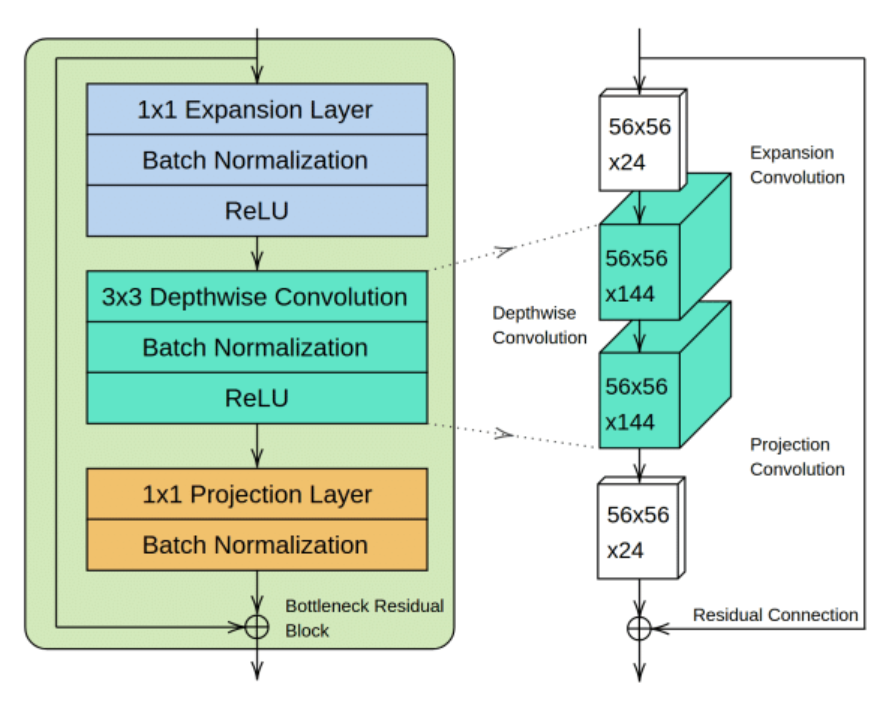


## Architecture

Input Layer 

&rarr; Initial Convolution (3x3 Conv with Stride=2) 

&rarr; Inverted Residual blocks 
- Expansion layer
- Depth-wise convolution
- projection layer
- residual skip connection

&rarr; Repeat Blocks 

&rarr; Final 1x1 

&rarr; Global Average Pooling &rarr; Fully connected layer 

&rarr; Softmax output


## Choosing the MobileNetV2 Model

The MobileNetV2 is selected as the baseline model for this project due to its balance between efficiency and performance.

Advantages
- Lightweight and efficient due to the depthwise separable convolutions
- Reduced computational costs
- Suitable for edge/environmental applications (the application is usually deployed in similar devices)
- Works well with small datasets 
- It is already pretrained on ImageNet hence understands basic visual features and needs low training time.

# Setting up GPU

In [ ]:
import torch

print('Torch Version: ', torch.__version__)
print('Cuda available: ', torch.cuda.is_available())

if torch.cuda.is_available():
  num_gpu = torch.cuda.device_count()
  print('GPU Available: ', num_gpu)

  for i in range(num_gpu):
    print('GPU: ', torch.cuda.get_device_name(i))
    print('GPU Memory: ', torch.cuda.get_device_properties(0).total_memory / 1e9)

else:
  print('No GPU Available')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Dependencies

In [2]:
conda activate pyEnv311


Note: you may need to restart the kernel to use updated packages.



CondaError: Run 'conda init' before 'conda activate'



In [3]:
conda install -n pyEnv311 torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121


Note: you may need to restart the kernel to use updated packages.


usage: conda-script.py [-h] [-v] [--no-plugins] [-V] COMMAND ...
conda-script.py: error: unrecognized arguments: --index-url https://download.pytorch.org/whl/cu121


In [4]:
conda install -n pyEnv311 install numpy matplotlib pandas scikit-learn seaborn

3 channel Terms of Service accepted
Channels:
 - defaults
Platform: win-64
Solving environment: failed

Note: you may need to restart the kernel to use updated packages.



PackagesNotFoundError: The following packages are not available from current channels:

  - install

Current channels:

  - defaults

To search for alternate channels that may provide the conda package you're
looking for, navigate to

    https://anaconda.org

and use the search bar at the top of the page.




# Device Configuration

In [5]:
# Lets consider the below configurations for our model

BATCH_SIZE = 32
IMG_SIZE = 224 # MobileNetV2 is pretained on 224 x 224
EPOCHS = 20
LEARNING_RATE = 1e-4

# Dataset Setup

The dataset consists of 7,581 RGB images categorized into multiple waste classes.

$$ Train = Val = Test = 2527 each $$

Classes:  ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash' ]

The dataset was split equally into training, validation, and test sets. While conventional splits such as 70:20:10 allocate more data for training, a balanced split was chosen due to the relatively small dataset size (~7.5K images), ensuring sufficient data in each subset for training, validation, and evaluation.

A balanced split is used to ensure reliable evaluation and fair comparison across models when working with a relatively small dataset.

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
#from google.colab import drive

#drive.mount('/content/drive')
data_path = '.../AI/Datasets/garbage_classification'

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(data_path+ "/train", transform=transform)
val_dataset = datasets.ImageFolder(data_path+ "/val", transform=transform)
test_dataset = datasets.ImageFolder(data_path+"/test", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print('Classes: ', train_dataset.classes)

Classes:  ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [7]:
#(batch_size, channels, height, width) - shape of image

train_images, train_labels = next(iter(train_loader))
print('Train Classes:', train_dataset.classes)
print(train_images.shape)
print(train_labels.shape)

test_images, test_labels = next(iter(test_loader))
print('Test Classes:', test_dataset.classes)
print(test_images.shape)
print(test_labels.shape)

Train Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
torch.Size([32, 3, 224, 224])
torch.Size([32])
Test Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
torch.Size([32, 3, 224, 224])
torch.Size([32])


In [8]:
print(train_dataset.class_to_idx)

{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


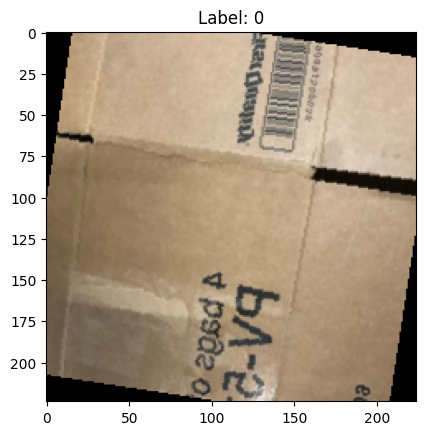

In [9]:
#Visual Check

import matplotlib.pyplot as plt

#.permute(1, 2, 0) - used as pytorch uses (channel, H, W) but matplotlib expects (H, W, C)
plt.imshow(train_images[3].permute(1, 2, 0))
plt.title(f'Label: {train_labels[3].item()}')

# You will get an image of size - 224 x 224
plt.show()

# MobileNetV2

For training of this model, we initialize using pretrained weights from ImageNet to leverage transfer learning.

ImageNet is a huge dataset with ~1M images and 1000 classes. Hence the model already learned certain features like edges, textures, etc. ie; the model already understands visual features.

For future-proof use - its best to use MobileNet_V2_Weights.DEFAULT

In [10]:
import torchvision.models as models
from torchvision.models import MobileNet_V2_Weights
import torch.nn as nn

num_classes = len(train_dataset.classes)

model = models.mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT) #or can use MobileNet_V2_Weights.IMAGENET1K_V1

In [11]:
model.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

From the above output, we can see that 20% of dropout is used to improve generalization and prevent overfitting.

Linear(in_features=1280, out_features=1000, bias=True) - says that we have 1280 features and 1000 classes as the petrained model was trained on ImageNet with 1000 classes.

In [12]:
model.classifier[1] = nn.Linear(model.last_channel, num_classes)

print(model.last_channel, '  ', num_classes)

model = model.to(device)

1280    6


In [13]:
images, label = next(iter(train_loader))

images = images.to(device)

outputs = model(images)

print('Output shape: ', outputs.shape)

Output shape:  torch.Size([32, 6])


# Defining Loss and Optimizer

The CrossEntropy loss function is chosen as it can handle multi-class problems and works directly with logits. It will also combine Softmax and log loss.

The Adam optimizer automatically adjusts learning rate for each parameter - faster convergence, smoother updates and less tuning required.

In [14]:
import torch.optim as optim

loss_crit = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Training Loop

In [15]:
def train_epoch(model, loader, optimizer, criterion):
  model.train()

  # initialising counters to track performance
  running_loss =0
  correct = 0
  total = 0

  for images, labels in loader:
    images = images.to(device)
    labels = labels.to(device)

    # reset optimizer before each batch as gradients accumulate by default.
    optimizer.zero_grad()

    outputs = model(images)
    loss = loss_crit(outputs, labels)

    loss.backward()
    optimizer.step()

    #Loss calculated for one batch
    running_loss += loss.item()

    #gives num_classes class scores per image
    #1 represents - look across dimension 1 (the class dimension)
    _, predicted = torch.max(outputs, 1)


    total += labels.size(0)
    correct += (predicted == labels).sum().item()

  accuracy = correct/total

  return running_loss/len(loader), accuracy

# Validation Loop

In [16]:
def validate(model, loader, criterion):

  model.eval()
  running_loss = 0
  total = 0
  correct = 0

  with torch.no_grad():
    for images, labels in loader:

      images = images.to(device)
      labels = labels.to(device)

      outputs = model(images)

      loss = criterion(outputs, labels)

      running_loss += loss.item()

      _ , predicted = torch.max(outputs, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()

    accuracy = correct/total
    return running_loss/len(loader), accuracy

In [17]:
import matplotlib.pyplot as plt

train_acc_list = []
val_acc_list = []
train_loss_list = []
val_loss_list = []

for epoch in range(EPOCHS):
  train_loss, train_acc = train_epoch(model, train_loader, optimizer, loss_crit)
  val_loss, val_acc = validate(model, val_loader, loss_crit)

  print(f'Epoch: [{epoch+1}/{EPOCHS}]')
  print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
  print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
  print("-" * 40)

  train_acc_list.append(train_acc)
  val_acc_list.append(val_acc)

  train_loss_list.append(train_loss)
  val_loss_list.append(val_loss)

Epoch: [1/20]
Train Loss: 1.2727 | Train Acc: 0.6051
Val Loss: 0.7255 | Val Acc: 0.7966
----------------------------------------
Epoch: [2/20]
Train Loss: 0.5868 | Train Acc: 0.8235
Val Loss: 0.3542 | Val Acc: 0.8951
----------------------------------------
Epoch: [3/20]
Train Loss: 0.3586 | Train Acc: 0.8935
Val Loss: 0.2000 | Val Acc: 0.9493
----------------------------------------
Epoch: [4/20]
Train Loss: 0.2403 | Train Acc: 0.9236
Val Loss: 0.1190 | Val Acc: 0.9759
----------------------------------------
Epoch: [5/20]
Train Loss: 0.1717 | Train Acc: 0.9501
Val Loss: 0.0729 | Val Acc: 0.9873
----------------------------------------
Epoch: [6/20]
Train Loss: 0.1303 | Train Acc: 0.9648
Val Loss: 0.0512 | Val Acc: 0.9901
----------------------------------------
Epoch: [7/20]
Train Loss: 0.0996 | Train Acc: 0.9739
Val Loss: 0.0325 | Val Acc: 0.9937
----------------------------------------
Epoch: [8/20]
Train Loss: 0.0864 | Train Acc: 0.9767
Val Loss: 0.0236 | Val Acc: 0.9960
---------

# Save the Model

In [ ]:
torch.save(model.state_dict(), '.../AI/Models/#1tansferlearning/mobilenet_v2.pth')

# Load the Model

In [19]:
device

device(type='cuda')

In [ ]:
model.to(device)

model.load_state_dict(
    torch.load(".../AI/Models/#1tansferlearning/mobilenet_v2.pth")
)


C:\Users\anish\AppData\Local\Temp\ipykernel_20568\1815339449.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("C:/Users/anish/Desktop/AI/Models/#1tansferlearni

<All keys matched successfully>

# Verification - Training

# 1. Plotting Accuracy







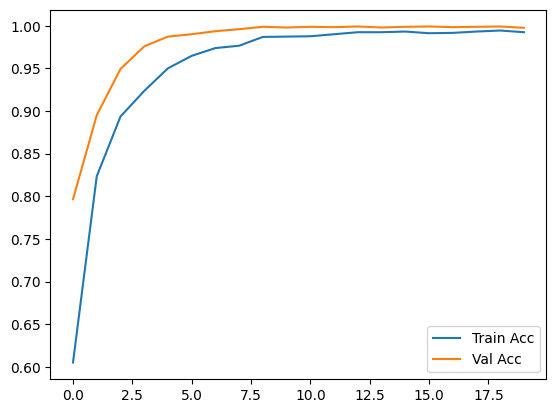

In [21]:
plt.plot(train_acc_list, label='Train Acc')
plt.plot(val_acc_list, label='Val Acc')
plt.legend()
plt.show()

# 2. Plotting Loss

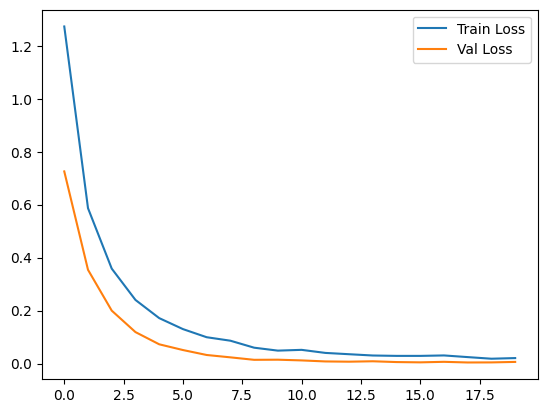

In [22]:
plt.plot(train_loss_list, label='Train Loss')
plt.plot(val_loss_list, label='Val Loss')
plt.legend()
plt.show()

From the plots, it can be observed that
1. The model learns very quickly within 2-3 epochs. This indicates good pretrained features and that the transfer learning works well.
2. No significant overfitting as Train = ~ Validation and improves together.
3. The loss decreases steadily - good training behavior.
4. High final accuracy and very low final loss

# 2. GPU check

In [23]:
print(next(model.parameters()).device)

cuda:0


In [ ]:
!nvidia-smi

# Evaluation on Test Data

In [25]:
model.eval()

test_loss = 0
total = 0
correct = 0

all_preds = []
all_labels = []

with torch.no_grad():
  for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)
    loss = loss_crit(outputs, labels)

    test_loss += loss.item()
    _, pred = torch.max(outputs, 1)

    total += labels.size(0)
    correct += (pred == labels).sum().item()

    all_preds.extend(pred.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())

test_acc = correct/total
test_loss = test_loss/len(test_loader)

print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

Test Loss: 0.0038
Test Accuracy: 0.9996


# Confusion Matrix

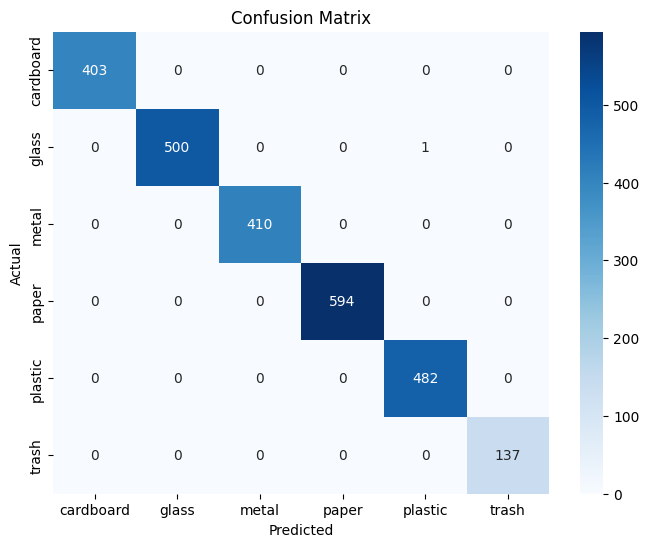

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_dataset.classes,
            yticklabels=test_dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Accuracy per class

In [27]:
class_correct = np.zeros(len(test_dataset.classes))
class_total = np.zeros(len(test_dataset.classes))

for label, pred in zip(all_labels, all_preds):
  if label == pred:
    class_correct[label] +=1
  class_total[label] += 1

per_class_acc = (class_correct/class_total)*100

for i, class_name in enumerate(test_dataset.classes):
  print(f'{class_name} : {per_class_acc[i]:.4f}')

cardboard : 100.0000
glass : 99.8004
metal : 100.0000
paper : 100.0000
plastic : 100.0000
trash : 100.0000


# Evaluation

The model was evaluated on a held-out test set to assess its generalization capability. The test accuracy closely matches the validation accuracy, indicating that the model generalizes well to unseen data and does not exhibit overfitting.

The confusion matrix shows that the model achieves near-perfect classification performance across all categories. Most predictions lie on the diagonal, indicating correct classification. It confirms that the model performs extremely well on the test set, with minimal errors and high reliability across all categories.

Given the high accuracy across all splits, further checks should be performed to confirm dataset quality and a larger complex dataset can be chosen to challenge the Model. Hence lets do that in the next project where we compare multiple architectures.